# 상품 Description을 이용한 상품 카테고리화

## Analyzing the product description
• Description에서 명사 추출

• Stemming

• 임베딩기법을 활용한 분석
## Defining the product categories
## Characterizing the content of clusters
## Stemming
• 공통 어근을 가진 단어를 하나로 묶는 과정

• Ex) {updated, update, updating} -> {update, update, update}

In [25]:
import pandas as pd

In [1]:
import pickle
with open('data/online_retail_clean.pkl', 'rb') as f:
    data = pickle.load(f)
data

,CustomerID,StockCode,Quantity,UnitPrice,Country,Description,Total
0,C12347,S16008,24,0.250000,Iceland,SMALL FOLDING SCISSOR(POINTED EDGE),24.250000
1,C12347,S17021,36,0.300000,Iceland,NAMASTE SWAGAT INCENSE,36.300000
2,C12347,S20665,6,2.950000,Iceland,RED RETROSPOT PURSE,8.950000
3,C12347,S20719,40,0.850000,Iceland,WOODLAND CHARLOTTE BAG,40.850000
4,C12347,S20780,12,4.650000,Iceland,BLACK EAR MUFF HEADPHONES,16.650000
...,...,...,...,...,...,...,...
264655,C18287,S84920,4,3.750000,United Kingdom,PINK FLOWER FABRIC PONY,7.750000
264656,C18287,S85039A,96,1.450000,United Kingdom,SET/4 RED MINI ROSE CANDLE IN BOWL,97.450000
264657,C18287,S85039B,120,1.516667,United Kingdom,S/4 IVORY MINI ROSE CANDLE IN BOWL,121.516667
264658,C18287,S85040A,48,1.650000,United Kingdom,S/4 PINK FLOWER CANDLES IN BOWL,49.650000


In [2]:
import nltk
#nltk.download('punkt','averaged_perceptron_tagger')

In [3]:
prod_info = data[['StockCode', 'Description']]
print(len(prod_info))
prod_info = prod_info.drop_duplicates('StockCode').reset_index(drop=True)
print(len(prod_info))

264660
3643


In [4]:
# 명사 추출을 위한 함수 정의 및 Stemmer 호출
is_noun = lambda pos: pos[:2] == 'NN'
stemmer = nltk.stem.SnowballStemmer('english')

In [5]:
# Keyword 저장을 위한 빈 딕셔너리 정의
key_roots = dict()
count_key = dict()
stemmed = []

In [9]:
# Stemming 처리 코드
for s in prod_info['Description']:
    lines = s.lower()
    tokenized = nltk.word_tokenize(lines)
    nouns = [word for (word, pos) in nltk.pos_tag(tokenized) if is_noun(pos)] 
    for t in nouns:
        t = t.lower()
        r = stemmer.stem(t)
        if r in key_roots:                
            key_roots[r].add(t)
            count_key[r] += 1                
        else:
            key_roots[r] = {t}
            count_key[r] = 1
    stemmed.append(' '.join([stemmer.stem(t.lower()) for t in nouns]))
prod_info['stemmed'] = stemmed

In [10]:
# Stemming 처리 결과
prod_info.head()

,StockCode,Description,stemmed
0,S16008,SMALL FOLDING SCISSOR(POINTED EDGE),fold scissor edg
1,S17021,NAMASTE SWAGAT INCENSE,namast swagat incens
2,S20665,RED RETROSPOT PURSE,retrospot purs
3,S20719,WOODLAND CHARLOTTE BAG,woodland charlott bag
4,S20780,BLACK EAR MUFF HEADPHONES,ear muff headphon


In [11]:
# Sklean의 CountVectorizer 활용
# 단어-index 쌍을 만들어 나중에 해석이 용이하도록 진행
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
tdm = cv.fit_transform(prod_info['stemmed'])
words = cv.get_feature_names()
word_dict = dict(enumerate(words))
word_dict
print(tdm.shape)

(3643, 1377)


In [14]:
# ModuleNotFoundError: No module named 'gensim' = !pip install gensim
#  Gensim 형태로 변환
from gensim.matutils import Sparse2Corpus
corpus = Sparse2Corpus(tdm.T)

In [15]:
# num_topics: 주제의 수(실험을 통해 결정)
# passes, iterations : 계산횟수(증가시키면 더 안정적 결과)
from gensim.models.ldamodel import LdaModel
lda = LdaModel(corpus=corpus, num_topics=10, passes=3, 
               iterations=100, id2word=word_dict, random_state=1234)

In [16]:
# show_topic() 메소드 사용
lda.show_topic(0)# 주제번호, topn=10

[('polkadot', 0.045375314),
 ('bottl', 0.03932377),
 ('water', 0.03452945),
 ('bowl', 0.0314767),
 ('pink', 0.030298043),
 ('retrospot', 0.020123668),
 ('parasol', 0.020112162),
 ('rabbit', 0.019350322),
 ('tag', 0.017062364),
 ('hanger', 0.016123246)]

In [19]:
# 워드클라우드로 확인
# !pip install WordCloud
from wordcloud import WordCloud

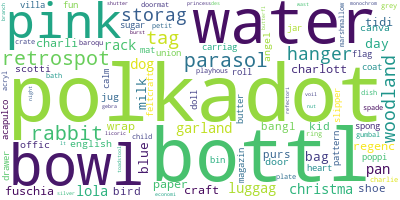

In [20]:
wc = WordCloud(background_color='white', width=400, height=200)
cloud = wc.fit_words(dict(lda.show_topic(0, topn=100)))
cloud.to_image()

In [21]:
# Tdm의 인덱스로 확인
raw = tdm[0]
doc = list(zip(raw.indices, raw.data))
doc

[(501, 1), (1080, 1), (436, 1)]

In [22]:
doc_words = [(words[i], n) for i, n in doc]
doc_words

[('fold', 1), ('scissor', 1), ('edg', 1)]

In [23]:
lda.get_document_topics(doc)

[(0, 0.025006317),
 (1, 0.025006317),
 (2, 0.7749431),
 (3, 0.025006317),
 (4, 0.025006317),
 (5, 0.025006317),
 (6, 0.025006317),
 (7, 0.025006317),
 (8, 0.025006317),
 (9, 0.025006317)]

In [26]:
# 전체 상품에 대한 처리
prod_topics = pd.DataFrame()
i=0
for raw in tdm:
    doc = list(zip(raw.indices, raw.data))
    temp = lda.get_document_topics(doc)
    temp = pd.DataFrame(temp)
    temp[0] = 'T' + temp[0].astype('str')
    temp = pd.pivot_table(temp, columns=0, values=1)
    temp['StockCode'] = prod_info.StockCode[i]
    prod_topics = pd.concat([prod_topics, temp])
    i += 1

In [27]:
# Pickle 형태로 저장
ata = data.merge(prod_topics, on='StockCode', how='left')
data.to_pickle('data/online_ratil_final.pkl')
data.head()

,CustomerID,StockCode,Quantity,UnitPrice,Country,Description,Total
0,C12347,S16008,24,0.25,Iceland,SMALL FOLDING SCISSOR(POINTED EDGE),24.25
1,C12347,S17021,36,0.30,Iceland,NAMASTE SWAGAT INCENSE,36.30
2,C12347,S20665,6,2.95,Iceland,RED RETROSPOT PURSE,8.95
3,C12347,S20719,40,0.85,Iceland,WOODLAND CHARLOTTE BAG,40.85
4,C12347,S20780,12,4.65,Iceland,BLACK EAR MUFF HEADPHONES,16.65
